In [ ]:
import numpy as np
import mne 
import pandas as pd
from scipy import signal
from scipy.signal import welch, filtfilt, butter, iirnotch


: 

In [ ]:
def load_eeg_channels(file_path, channels, duration):
    channels = int(channels)
    duration = int(duration)
    raw = mne.io.read_raw_bdf(file_path, preload=True) 
    df = raw.to_data_frame()
    df = df.iloc[:duration*fs_original, :channels]
    return df

def resample(eeg_df, fs_original, fs):
    eeg_array = eeg_df.values.T
    num_samples = int(eeg_array.shape[1] * fs / fs_original)
    resampled_eeg = np.zeros((eeg_array.shape[0], num_samples))
    for i in range(eeg_array.shape[0]):
        resampled_eeg[i] = np.interp(np.linspace(0, eeg_array.shape[1], num=num_samples, endpoint=False),
            np.arange(eeg_array.shape[1]),
            eeg_array[i]
        )
    return pd.DataFrame(resampled_eeg.T, columns=eeg_df.columns)

def filter_eeg(x, fs=512):
    sos_high = signal.butter(4, 0.5, btype="high", fs=fs, output="sos")
    x = signal.sosfiltfilt(sos_high, x)

    b, a = signal.iirnotch(50, Q=30, fs=fs)
    x = signal.filtfilt(b, a, x)

    return x



In [7]:
path = r"C:\Users\kngu0289\OneDrive - The University of Sydney (Staff)\\2. SHARED SHORTCUTS\Yvonne Tran's files - EEG analysis" 
name = "002baseline1.2.bdf"
fs_original = 2048
fs = 512
file_path = f"{path}\\{name}"

eeg = load_eeg_channels(file_path, channels=65, duration=120)
eeg = resample(eeg, fs_original, fs)
eeg_freq = filter_eeg(eeg.values.T)


eeg.values.T

Extracting BDF parameters from C:\Users\kngu0289\OneDrive - The University of Sydney (Staff)\\2. SHARED SHORTCUTS\Yvonne Tran's files - EEG analysis\002baseline1.2.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 247807  =      0.000 ...   121.000 secs...


array([[0.00000000e+00, 1.95312500e-03, 3.90625000e-03, ...,
        1.19994141e+02, 1.19996094e+02, 1.19998047e+02],
       [8.55254201e+04, 8.55303263e+04, 8.50662022e+04, ...,
        8.33650178e+04, 8.33797366e+04, 8.28249251e+04],
       [8.90318824e+04, 8.90253511e+04, 8.85710707e+04, ...,
        8.69477300e+04, 8.69451987e+04, 8.64047310e+04],
       ...,
       [6.45173652e+04, 6.45381464e+04, 6.40530535e+04, ...,
        6.28311808e+04, 6.28819307e+04, 6.23196505e+04],
       [4.38168722e+04, 4.38369034e+04, 4.33653105e+04, ...,
        4.23615311e+04, 4.23876873e+04, 4.18448133e+04],
       [7.74458725e+04, 7.74660600e+04, 7.69846234e+04, ...,
        7.53228764e+04, 7.53454389e+04, 7.47923149e+04]],
      shape=(65, 61440))

In [109]:
eeg_freq

array([[-8.97485241e-02, -8.88267361e-02, -8.79168540e-02, ...,
         2.30634574e-13,  2.25460157e-13,  2.05875814e-13],
       [ 1.15322795e+02,  1.25959607e+02, -3.59044194e+02, ...,
         7.08890943e+02,  7.25272772e+02,  1.33646881e+02],
       [ 1.13832654e+02,  1.12916948e+02, -3.62414430e+02, ...,
         7.16857274e+02,  7.15794328e+02,  1.38589841e+02],
       ...,
       [ 1.05314862e+02,  1.32467569e+02, -3.71774042e+02, ...,
         6.68545703e+02,  7.21583470e+02,  1.24555431e+02],
       [ 1.07622585e+02,  1.29540109e+02, -3.64225417e+02, ...,
         6.63862091e+02,  6.87043682e+02,  1.07187336e+02],
       [ 1.10976816e+02,  1.35198370e+02, -3.67474479e+02, ...,
         6.94384334e+02,  7.16951058e+02,  1.27684844e+02]],
      shape=(65, 61440))

Saved -> ica_components.png


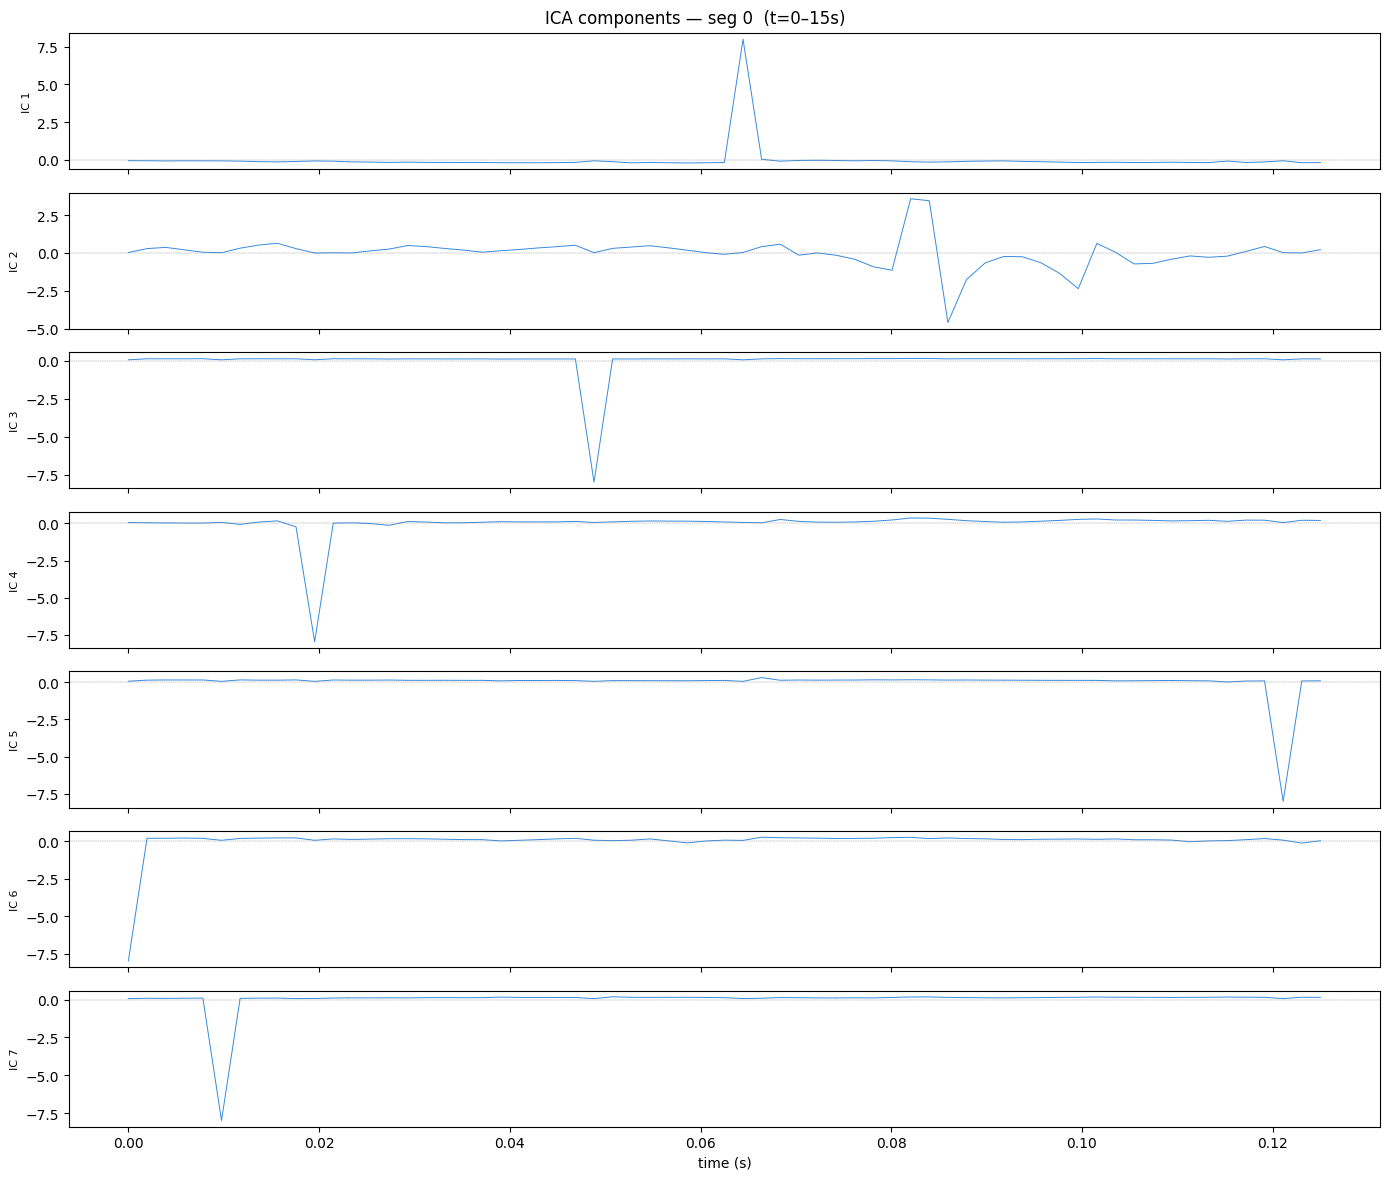

In [106]:
import matplotlib.pyplot as plt
import matplotlib.widgets as widgets
from scipy.signal import welch, filtfilt, butter, iirnotch
from scipy.integrate import simpson
from scipy import signal
from scipy.signal import butter, filtfilt
from sklearn.decomposition import FastICA


seg=0
FS = fs

eeg = eeg_freq
 
# slice 15s segment
start = seg * 15 * FS
end   = (seg + 1) * 15 * FS
segment = eeg[start:end]          # (3840, 7)
time    = np.arange(len(segment)) / FS
 
# run ICA
ica        = FastICA(n_components=7, random_state=42, max_iter=1000)
components = ica.fit_transform(segment)   # (3840, 7)
 
# plot
n_comp = components.shape[1]
fig, axes = plt.subplots(n_comp, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"ICA components — seg {seg}  (t={seg*15}–{(seg+1)*15}s)", fontsize=12)
 
for i, ax in enumerate(axes):
    sig = components[:, i]
    ax.plot(time, sig, linewidth=0.7, color="#378ADD")
    ax.set_ylabel(f"IC {i+1}", fontsize=8)
    ax.axhline(0, color="gray", linewidth=0.3, linestyle="--")
 
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.savefig("ica_components.png", dpi=150)
print("Saved -> ica_components.png")
plt.show()

In [107]:
components.shape

(65, 7)